# Lagrangiano Aumentado com TuRBO (BoTorch) e CMA-ES
### Benchmark COCO/BBOB-constrained · dims 2/3/5/10 · 15 funções · 3 seeds · perfis de desempenho (Dolan & Moré) e tempo

Versão estendida do estudo. Mudanças em relação à anterior:

1. **TuRBO reimplementado em BoTorch/GPyTorch** (GP `SingleTaskGP`, kernel Matérn-5/2 ARD,
   Thompson Sampling em região de confiança) — **agnóstico de dispositivo** (GPU se houver).
2. **Múltiplas dimensões** $d\in\{2,3,5,10\}$ com **orçamento escalado** $\texttt{inner\_budget}=k\cdot d$.
3. **15 funções** da suíte `bbob-constrained` (a suíte tem 54; usamos `function_indices` 1–15).
4. **3 seeds** por (solver, problema), agregadas pela **mediana**.
5. **Perfis de desempenho por dimensão + perfil agregado**, e um **gráfico de tempo**
   (tempo de parede no dispositivo ativo — GPU quando disponível).

> **GPU × CPU (leia antes de rodar).** Neste regime (GP com poucos pontos, $d\le10$,
> orçamento de centenas de avaliações) o gargalo é a fatoração de Cholesky $\mathcal{O}(n^3)$
> com $n$ pequeno; o *overhead* de kernels da GPU costuma dominar e a **CPU empata ou ganha**.
> A GPU compensa ao escalar: orçamentos grandes ($n$ na casa dos milhares), muitos candidatos
> no Thompson Sampling, TuRBO com várias regiões em *batch* ou dimensões altas. O código roda
> nos dois; o gráfico de tempo deixa você medir o trade-off na sua máquina.

## 0. Instalação, dispositivo e *presets*

Dependências: `coco-experiment` (`cocoex`), `botorch` (puxa `torch`+`gpytorch`), `cma`,
`scikit-learn` (opcional), `numpy`, `matplotlib`.

In [1]:
# %pip install coco-experiment botorch cma numpy matplotlib

import time, math, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
warnings.filterwarnings("ignore")

try:
    import cocoex; HAS_COCO = True
except Exception as e:
    HAS_COCO = False; print("cocoex indisponível -> backend sintético.", e)
import cma

# ---- dispositivo (GPU se disponível) ----
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.double
print(f"torch {torch.__version__} | DEVICE = {DEVICE} | cuda? {torch.cuda.is_available()}")
print(f"cocoex: {HAS_COCO} | cma: {cma.__version__}")

torch 2.10.0+cu128 | DEVICE = cpu | cuda? False
cocoex: True | cma: 4.4.4


### *Presets* do experimento

- **`full`** (padrão) — o estudo pedido: $d\in\{2,3,5,10\}$, 15 funções, 3 seeds.
- **`preview`** — versão reduzida (~2 min) só para validar os gráficos.

**Parâmetros (todos ajustáveis):**

- **Orçamento.** Nº total de avaliações de $f$/restrições por subproblema·iteração externa:
  `inner_budget = budget_per_dim * d`, `total = n_outer * inner_budget`. Aumentar
  `budget_per_dim`/`n_outer` eleva as taxas de sucesso ($\rho_s^\ast$) ao custo de tempo
  (convenção BBOB: orçamento cresce com $d$).
- **`max_gp_points`.** A cada passo o TuRBO ajusta o GP apenas nos **melhores
  `max_gp_points`** pontos. Isso limita o custo $\mathcal{O}(n^3)$ do GP, que de outro modo
  explodiria conforme o orçamento cresce — é o que torna o `full` viável. Valores típicos:
  128–512 (maior = modelo mais rico, porém mais lento).

> **Tempo.** O `full` é pesado: em CPU pode levar **várias horas** (o gargalo é o TuRBO; $d=10$
> domina). Em GPU, bem menos. **Calibre primeiro** (célula da seção 6) rodando só `dims=[2]`
> para cronometrar uma dimensão e extrapolar antes de soltar tudo. Se ficar inviável, reduza
> nesta ordem: `funs` (ex.: 1–8), depois `n_outer`/`budget_per_dim`, depois tire `d=10`.

In [2]:
PRESET = "full"        # estudo completo. Use "preview" p/ um teste rápido (~2 min)

PRESETS = {
    "preview": dict(dims=[2, 3, 5],     funs=list(range(1, 5)),  seeds=[0, 1],
                    budget_per_dim=6,  n_outer=3, n_cand_cap=512,  max_gp_points=128),
    # ---- estudo sério pedido: dims 2/3/5/10, 15 funções, 3 seeds ----
    "full":    dict(dims=[2, 3, 5, 10], funs=list(range(1, 55)), seeds=[0, 1, 2],
                    budget_per_dim=10, n_outer=8, n_cand_cap=1500, max_gp_points=256),
}
CFG = PRESETS[PRESET]
print(PRESET, CFG)

full {'dims': [2, 3, 5, 10], 'funs': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54], 'seeds': [0, 1, 2], 'budget_per_dim': 10, 'n_outer': 8, 'n_cand_cap': 1500, 'max_gp_points': 256}


## 1. Núcleo: rastreador, Lagrangiano Aumentado (PHR) e CMA-ES

`Tracked` registra a trajetória `(n_avaliações, melhor_f_viável)` do problema **original**
(viabilidade $g_j(x)\le0$, tolerância $10^{-4}$). `auglag` resolve
$\min f$ s.a. $g\le0$ por uma sequência de subproblemas
$L_A(x,\lambda,\mu)=f(x)+\tfrac{1}{2\mu}\sum_j(\max\{0,\lambda_j+\mu g_j\}^2-\lambda_j^2)$,
atualizando multiplicadores $\lambda_j\leftarrow\max\{0,\lambda_j+\mu g_j\}$ e a penalização
$\mu$. O solver interno (TuRBO ou CMA-ES) minimiza $L_A$ na caixa.

In [3]:
import numpy as np

class Tracked:
    """Envolve um problema com restricoes g(x)<=0 e registra a trajetoria."""
    def __init__(self, f, g, lb, ub, name):
        self.f, self.g = f, g
        self.lb, self.ub = np.asarray(lb,float), np.asarray(ub,float)
        self.dim = len(lb); self.name = name
        self.n = 0; self.hist = []  # (n_eval, best_feasible_f or inf)
        self.best_f = np.inf; self.best_x = None
    def evaluate(self, x):
        x = np.clip(np.asarray(x,float), self.lb, self.ub)
        fv = float(self.f(x)); gv = np.atleast_1d(self.g(x)).astype(float)
        self.n += 1
        viol = float(np.max(np.maximum(0.0, gv))) if gv.size else 0.0
        if viol <= 1e-4 and fv < self.best_f:
            self.best_f = fv; self.best_x = x.copy()
        self.hist.append((self.n, self.best_f))
        return fv, gv

In [4]:
def auglag(prob, inner_solver, x0=None, mu0=10.0, tau=2.0, eta=0.5,
           n_outer=6, inner_budget=60, seed=0):
    rng = np.random.default_rng(seed)
    d = prob.dim
    x = (prob.lb+prob.ub)/2 if x0 is None else np.asarray(x0,float)
    _, g = prob.evaluate(x)
    lam = np.zeros(g.size); mu = mu0; prev_viol = np.inf
    for _ in range(n_outer):
        def LA(z):
            fv, gv = prob.evaluate(z)
            pen = np.sum(np.maximum(0.0, lam+mu*gv)**2 - lam**2)/(2*mu)
            return fv + pen
        x = inner_solver(LA, prob.lb, prob.ub, inner_budget, x, rng)
        _, g = prob.evaluate(x)
        lam = np.maximum(0.0, lam+mu*g)
        viol = float(np.max(np.maximum(0.0, g))) if g.size else 0.0
        if viol > eta*prev_viol: mu *= tau
        prev_viol = viol
    return prob.best_x, prob.best_f

In [5]:
def cmaes_solver(fun, lb, ub, budget, x0, rng):
    import cma
    sigma0 = 0.25*np.mean(ub-lb)
    es = cma.CMAEvolutionStrategy(list(np.clip(x0,lb,ub)), sigma0,
            {'bounds':[list(lb),list(ub)],'maxfevals':budget,'verbose':-9,
             'seed':int(rng.integers(1e9))})
    best_x, best_v = x0, np.inf
    while not es.stop():
        X = es.ask(); V = [fun(z) for z in X]; es.tell(X, V)
        i = int(np.argmin(V))
        if V[i] < best_v: best_v, best_x = V[i], np.asarray(X[i])
    return best_x

## 2. Solver interno — TuRBO em BoTorch (GPU-ready)

TuRBO-1 fiel ao tutorial do BoTorch: a cada passo (i) padroniza $Y=-f$ (BoTorch **maximiza**),
(ii) ajusta `SingleTaskGP` com Matérn-5/2 ARD, (iii) constrói a **região de confiança** de
lado $L$ ao redor do incumbente, com os lados ponderados pelos *length-scales*, (iv) gera
candidatos por Sobol + máscara de perturbação e escolhe o próximo por **Thompson Sampling**
(`MaxPosteriorSampling`), (v) adapta $L$ (expande em sequência de sucessos, contrai em
fracassos; *restart* quando $L<L_{\min}$). Tensores em `DEVICE`/`DTYPE` — roda na GPU se houver.

In [6]:
import math, numpy as np, torch
from dataclasses import dataclass
from torch.quasirandom import SobolEngine
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.models.transforms.outcome import Standardize
from botorch.generation import MaxPosteriorSampling
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.constraints import Interval
import warnings; warnings.filterwarnings("ignore")

@dataclass
class TRState:
    dim: int
    length: float = 0.8
    length_min: float = 0.5**7
    length_max: float = 1.6
    success_counter: int = 0
    failure_counter: int = 0
    success_tol: int = 3
    best_value: float = -float("inf")
    restart: bool = False
    def __post_init__(self):
        self.failure_tol = math.ceil(max(4.0, self.dim))

def _update_state(st, y_next):
    ybest = float(y_next.max())
    if ybest > st.best_value + 1e-3*abs(st.best_value):
        st.success_counter += 1; st.failure_counter = 0
    else:
        st.success_counter = 0; st.failure_counter += 1
    if st.success_counter == st.success_tol:
        st.length = min(2.0*st.length, st.length_max); st.success_counter = 0
    elif st.failure_counter == st.failure_tol:
        st.length /= 2.0; st.failure_counter = 0
    st.best_value = max(st.best_value, ybest)
    if st.length < st.length_min: st.restart = True
    return st

def turbo_botorch_solver(fun, lb, ub, budget, x0, rng,
                         device="cpu", dtype=torch.double, n_cand_cap=2000,
                         max_gp_points=256):
    """TuRBO-1 (BoTorch): minimiza `fun` em [lb,ub]. Internamente no cubo [0,1]^d,
    maximiza Y=-f via Thompson Sampling dentro de uma região de confiança."""
    dev = torch.device(device); d = len(lb)
    lb_t = torch.tensor(lb, dtype=dtype, device=dev)
    ub_t = torch.tensor(ub, dtype=dtype, device=dev)
    seed = int(rng.integers(1e9))
    torch.manual_seed(seed)
    to_real = lambda U: lb_t + (ub_t - lb_t) * U
    f_unit = lambda U: torch.tensor(
        [-float(fun((lb_t + (ub_t-lb_t)*u).cpu().numpy())) for u in U],
        dtype=dtype, device=dev).unsqueeze(-1)            # maximizamos -f

    n_init = min(2*d+2, max(4, budget//3))
    sob = SobolEngine(d, scramble=True, seed=seed)
    X = sob.draw(n_init).to(dtype=dtype, device=dev)
    X[0] = torch.tensor(np.clip((np.asarray(x0)-lb)/(ub-lb),0,1), dtype=dtype, device=dev)
    Y = f_unit(X); used = n_init
    st = TRState(dim=d); st.best_value = float(Y.max())

    while used < budget:
        if st.restart:                                    # reinicia região colapsada
            ni = min(2*d+2, budget-used)
            if ni <= 0: break
            Xn = SobolEngine(d, scramble=True, seed=int(rng.integers(1e9))).draw(ni).to(dtype=dtype, device=dev)
            Yn = f_unit(Xn); used += ni
            X = torch.cat([X, Xn]); Y = torch.cat([Y, Yn])
            st = TRState(dim=d); st.best_value = float(Y.max()); continue

        # subconjunto p/ o GP: melhores max_gp_points (limita O(n^3) em orçamentos grandes)
        if X.shape[0] > max_gp_points:
            sel = torch.topk(Y.view(-1), max_gp_points).indices
            Xg, Yg = X[sel], Y[sel]
        else:
            Xg, Yg = X, Y
        Ytr = (Yg - Yg.mean()) / (Yg.std() + 1e-9)
        likelihood = GaussianLikelihood(noise_constraint=Interval(1e-8, 1e-1))
        kernel = ScaleKernel(MaternKernel(nu=2.5, ard_num_dims=d,
                                          lengthscale_constraint=Interval(0.005, 4.0)))
        gp = SingleTaskGP(Xg, Ytr, likelihood=likelihood, covar_module=kernel)
        mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
        try: fit_gpytorch_mll(mll)
        except Exception: pass

        # região de confiança ponderada pelos lengthscales
        x_c = X[Y.argmax()].clone()
        ls = gp.covar_module.base_kernel.lengthscale.detach().view(-1)
        w = ls / ls.mean(); w = w / torch.prod(w).pow(1.0/d)
        tr_lb = torch.clamp(x_c - w*st.length/2, 0.0, 1.0)
        tr_ub = torch.clamp(x_c + w*st.length/2, 0.0, 1.0)

        n_cand = min(n_cand_cap, max(200, 100*d))
        pert = SobolEngine(d, scramble=True, seed=int(rng.integers(1e9))).draw(n_cand).to(dtype=dtype, device=dev)
        pert = tr_lb + (tr_ub - tr_lb) * pert
        prob = min(1.0, 20.0/d)
        mask = torch.rand(n_cand, d, device=dev) <= prob
        ind = torch.where(mask.sum(dim=1) == 0)[0]
        mask[ind, torch.randint(0, d, (len(ind),), device=dev)] = True
        Xcand = x_c.expand(n_cand, d).clone()
        Xcand[mask] = pert[mask]

        ts = MaxPosteriorSampling(model=gp, replacement=False)
        with torch.no_grad(): Xnext = ts(Xcand, num_samples=1)
        Ynext = f_unit(Xnext); used += 1
        st = _update_state(st, Ynext)
        X = torch.cat([X, Xnext]); Y = torch.cat([Y, Ynext])

    best = to_real(X[Y.argmax()]).detach().cpu().numpy()
    return best

## 3. Perfis de desempenho (Dolan & Moré) — utilitários

$r_{p,s}=t_{p,s}/\min_{s'}t_{p,s'}$ e $\rho_s(\tau)=\tfrac1{n_p}|\{p:r_{p,s}\le\tau\}|$.
Falhas ficam como $+\infty$ (nunca satisfazem $r\le\tau$ finito), então a curva achata em
$\rho_s^\ast$ = fração resolvida. `draw_profile` desenha em um eixo (para grades por dimensão);
serve tanto para custo = avaliações quanto para custo = tempo.

In [7]:
def perf_ratios(cost):
    """cost: {solver: array}; inf=falha. Retorna (ratios (n_s,n_p'), solvers, rM)."""
    solvers = list(cost)
    Cm = np.array([cost[s] for s in solvers], float)
    with np.errstate(invalid="ignore"):
        best = np.nanmin(np.where(np.isinf(Cm), np.nan, Cm), axis=0)
    valid = np.isfinite(best)
    Cm, best = Cm[:, valid], best[valid]
    ratios = Cm / best
    finite = ratios[np.isfinite(ratios)]
    rM = finite.max() * 1.2 if finite.size else 2.0
    return ratios, solvers, rM

def draw_profile(ax, cost, logscale=False, title=""):
    ratios, solvers, rM = perf_ratios(cost)
    if logscale:
        grid = np.linspace(0, max(np.log2(rM) + 0.2, 0.2), 300)
        xf = lambda r: np.log2(r)
        ax.set_xlabel(r"$\tau$ (escala $\log_2$)")
    else:
        grid = np.linspace(1, rM, 300); xf = lambda r: r
        ax.set_xlabel(r"$\tau$")
    for i, s in enumerate(solvers):
        y = [np.mean(xf(ratios[i]) <= t) for t in grid]
        ax.step(grid, y, where="post", lw=2, label=s)
    ax.set_ylim(-0.02, 1.02); ax.grid(alpha=0.3)
    ax.set_ylabel(r"$\rho_s(\tau)$"); 
    if title: ax.set_title(title, fontsize=10)
    ax.legend(loc="lower right", fontsize=8)

def profile_metrics(cost):
    ratios, solvers, _ = perf_ratios(cost)
    return {s: dict(wins=float(np.mean(ratios[i] <= 1.0)),
                    robust=float(np.mean(np.isfinite(ratios[i]))))
            for i, s in enumerate(solvers)}

## 4. Interface de problemas e o *runner* (multi-dim, multi-seed, com tempo)

Para cada dimensão criamos a suíte `bbob-constrained` com `function_indices` 1–15 e instância 1.
Rodamos cada (solver, seed) sobre os problemas **vivos** e guardamos só dados: `best_f`,
trajetória `hist`, `evals`, e o **tempo de parede** do `auglag` (no `DEVICE`).

In [8]:
def make_synthetic():
    P=[]
    P.append(dict(name="sphere_lin", fnum=1, lb=[-5,-5], ub=[5,5],
                  f=lambda x: np.sum(x**2), g=lambda x: np.array([1-np.sum(x)])))
    P.append(dict(name="rosen_disk", fnum=2, lb=[-2,-2], ub=[2,2],
                  f=lambda x:(1-x[0])**2+100*(x[1]-x[0]**2)**2,
                  g=lambda x: np.array([x[0]**2+x[1]**2-2])))
    P.append(dict(name="g06", fnum=3, lb=[13,0], ub=[100,100],
                  f=lambda x:(x[0]-10)**3+(x[1]-20)**3,
                  g=lambda x: np.array([-(x[0]-5)**2-(x[1]-5)**2+100,
                                        (x[0]-6)**2+(x[1]-5)**2-82.81])))
    return P

def make_turbo(device, n_cand_cap, max_gp_points):
    def solver(fun, lb, ub, b, x0, rng):
        return turbo_botorch_solver(fun, lb, ub, b, x0, rng, device=device,
                                    dtype=DTYPE, n_cand_cap=n_cand_cap,
                                    max_gp_points=max_gp_points)
    return solver

def run_study(cfg, device=DEVICE):
    SOLVERS = {"TuRBO": make_turbo(device, cfg["n_cand_cap"],
                                              cfg["max_gp_points"]),
               "CMA-ES":          cmaes_solver}
    data = {}  # data[d][solver][fnum] = [ {best_f,hist,evals,time}, ... por seed ]
    for d in cfg["dims"]:
        inner_budget = cfg["budget_per_dim"] * d
        data[d] = {s: {} for s in SOLVERS}
        for sname, solver in SOLVERS.items():
            for seed in cfg["seeds"]:
                print(f"  [d={d}] {sname} | seed={seed} | inner_budget={inner_budget}",
                      flush=True)
                if HAS_COCO:
                    funs_str = ",".join(map(str, cfg["funs"]))
                    suite = cocoex.Suite("bbob-constrained", "",
                        f"dimensions: {d} function_indices: {funs_str} instance_indices: 1")
                    iterator = suite
                    def wrap(p):
                        fnum = int(p.id.split("_f")[1][:3])
                        return Tracked(lambda x, pp=p: pp(x),
                                       lambda x, pp=p: np.atleast_1d(pp.constraint(x)),
                                       list(p.lower_bounds), list(p.upper_bounds), p.id), fnum
                    for p in iterator:
                        P, fnum = wrap(p)
                        t0 = time.perf_counter()
                        auglag(P, solver, n_outer=cfg["n_outer"],
                               inner_budget=inner_budget, seed=seed)
                        dt = time.perf_counter() - t0
                        data[d][sname].setdefault(fnum, []).append(
                            dict(best_f=P.best_f, hist=list(P.hist), evals=P.n, time=dt))
                else:
                    if d != 2: continue  # sintético só tem d=2
                    for dd in make_synthetic():
                        P = Tracked(dd["f"], dd["g"], dd["lb"], dd["ub"], dd["name"])
                        t0 = time.perf_counter()
                        auglag(P, solver, n_outer=cfg["n_outer"],
                               inner_budget=inner_budget, seed=seed)
                        dt = time.perf_counter() - t0
                        data[d][sname].setdefault(dd["fnum"], []).append(
                            dict(best_f=P.best_f, hist=list(P.hist), evals=P.n, time=dt))
    return data, list(SOLVERS)

## 5. Agregação por mediana das seeds

Por $(d,\text{func})$: $f^\star$ = melhor valor viável entre **todos** os solvers/seeds; alvo
$=f^\star+\varepsilon\max(1,|f^\star|)$, $\varepsilon=10^{-2}$. Custo (avaliações até o alvo) e
tempo são agregados pela **mediana** das seeds — um solver que resolve em 2/3 das seeds tem
mediana finita.

In [9]:
def aggregate(data, solvers, eps=1e-2):
    cost_by_dim, time_by_dim, funcs_by_dim = {}, {}, {}
    for d, perdim in data.items():
        funcs = sorted(perdim[solvers[0]].keys())
        if not funcs:  # dimensão sem dados (ex.: sintético d!=2)
            continue
        funcs_by_dim[d] = funcs
        cost = {s: np.full(len(funcs), np.inf) for s in solvers}
        tmat = {s: np.full(len(funcs), np.nan) for s in solvers}
        for j, fn in enumerate(funcs):
            fbest = np.inf
            for s in solvers:
                for rec in perdim[s].get(fn, []):
                    if np.isfinite(rec["best_f"]): fbest = min(fbest, rec["best_f"])
            for s in solvers:
                recs = perdim[s].get(fn, [])
                ev = []
                for rec in recs:
                    if np.isfinite(fbest):
                        target = fbest + eps * max(1.0, abs(fbest))
                        hit = [k for (k, bf) in rec["hist"] if bf <= target]
                        ev.append(hit[0] if hit else np.inf)
                    else:
                        ev.append(np.inf)
                cost[s][j] = np.median(ev) if ev else np.inf
                tmat[s][j] = np.median([r["time"] for r in recs]) if recs else np.nan
        cost_by_dim[d], time_by_dim[d] = cost, tmat
    return cost_by_dim, time_by_dim, funcs_by_dim

## 6. Executando o estudo

Os prints mostram o progresso `[d=.. solver | seed=..]`. **Antes do `full` completo**, vale
calibrar: na célula abaixo, descomente a linha `CFG = {**CFG, "dims": [2]}` para rodar só
$d=2$, medir o tempo e extrapolar (grosso modo, $d=10$ custa bem mais que $d=2$). Depois
comente de novo e rode o estudo inteiro — de preferência em GPU e/ou em *background*.

In [10]:
# CFG = {**CFG, "dims": [2]}      # <- descomente p/ calibrar só d=2 antes do estudo todo

t_start = time.perf_counter()
data, SOLVERS = run_study(CFG, device=DEVICE)
cost_by_dim, time_by_dim, funcs_by_dim = aggregate(data, SOLVERS)
print(f"concluído em {time.perf_counter()-t_start:.1f}s no DEVICE={DEVICE}")
print("dimensões com dados:", list(cost_by_dim))
for d in cost_by_dim:
    print(f"  d={d}: {len(funcs_by_dim[d])} funções -> {funcs_by_dim[d]}")

  [d=2] TuRBO | seed=0 | inner_budget=20


  [d=2] TuRBO | seed=1 | inner_budget=20


  [d=2] TuRBO | seed=2 | inner_budget=20


  [d=2] CMA-ES | seed=0 | inner_budget=20


  [d=2] CMA-ES | seed=1 | inner_budget=20


...

  [d=10] TuRBO | seed=2 | inner_budget=100


  [d=10] CMA-ES | seed=0 | inner_budget=100


  [d=10] CMA-ES | seed=1 | inner_budget=100


  [d=10] CMA-ES | seed=2 | inner_budget=100


concluído em 29029.9s no DEVICE=cpu
dimensões com dados: [2, 3, 5, 10]
  d=2: 54 funções -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54]
  d=3: 54 funções -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54]
  d=5: 54 funções -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54]
  d=10: 54 funções -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54]


## 7. Perfis de desempenho **por dimensão** (escala $\log_2$)

Uma curva por solver, um painel por $d\in\{2,3,5,10\}$. Curva mais **alta/à esquerda** domina;
a altura do platô é a robustez $\rho_s^\ast$.

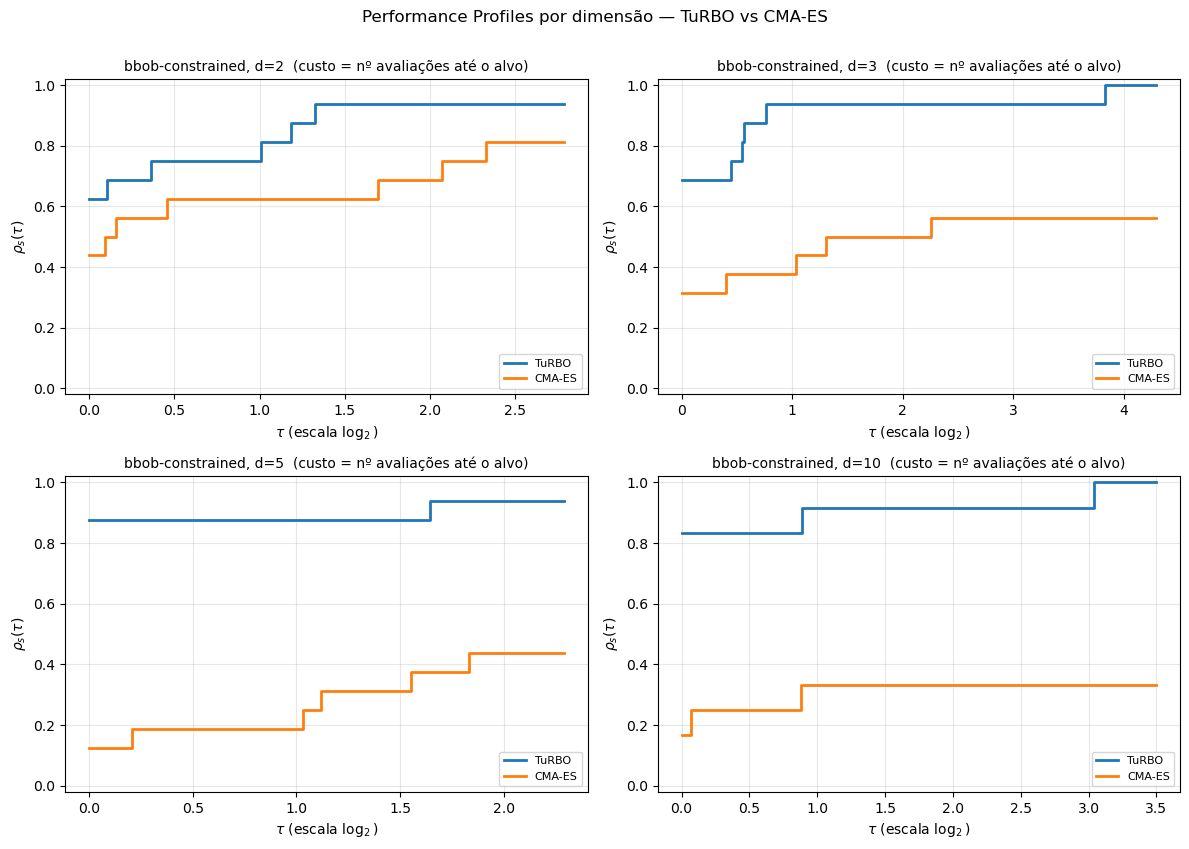

In [11]:
dims = list(cost_by_dim)
ncol = 2; nrow = int(np.ceil(len(dims)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 4.2*nrow), squeeze=False)
for ax in axes.flat: ax.axis("off")
for k, d in enumerate(dims):
    ax = axes.flat[k]; ax.axis("on")
    draw_profile(ax, cost_by_dim[d], logscale=True,
                 title=f"bbob-constrained, d={d}  (custo = nº avaliações até o alvo)")
fig.suptitle("Performance Profiles por dimensão — TuRBO vs CMA-ES",
             y=1.005, fontsize=12)
plt.tight_layout(); plt.show()

## 8. Perfil **agregado** (todos os problemas de todas as dimensões)

Empilha os problemas de todas as dimensões num único conjunto $\mathcal{P}$ — visão global.

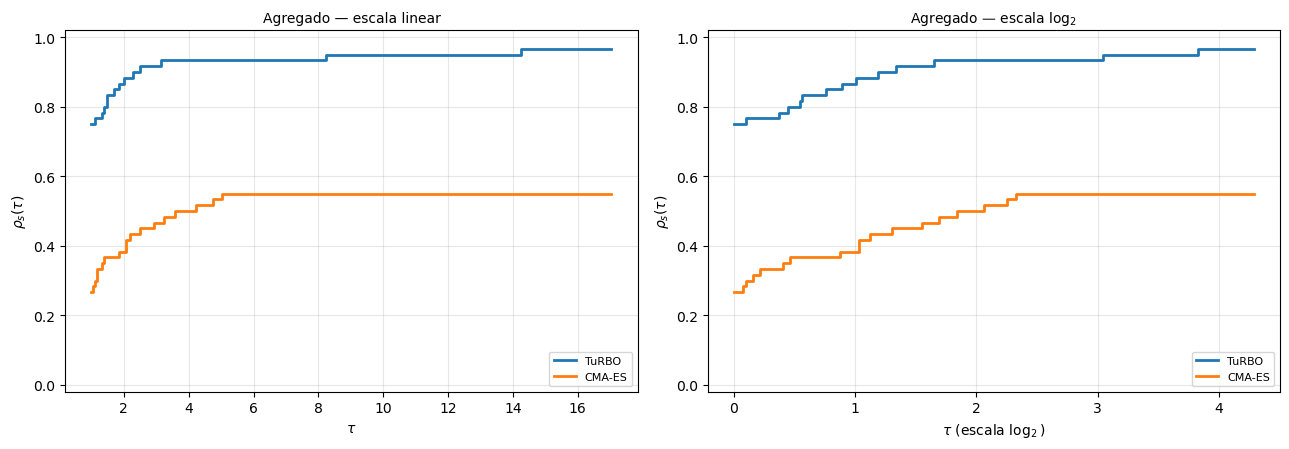

solver               rho_s(1) vitórias   rho_s* robustez
TuRBO                            0.750             0.967
CMA-ES                           0.267             0.550


In [12]:
cost_all = {s: np.concatenate([cost_by_dim[d][s] for d in dims]) for s in SOLVERS}
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
draw_profile(ax[0], cost_all, logscale=False, title="Agregado — escala linear")
draw_profile(ax[1], cost_all, logscale=True,  title="Agregado — escala $\\log_2$")
plt.tight_layout(); plt.show()

m = profile_metrics(cost_all)
print(f"{'solver':<18}{'rho_s(1) vitórias':>20}{'rho_s* robustez':>18}")
for s in m: print(f"{s:<18}{m[s]['wins']:>20.3f}{m[s]['robust']:>18.3f}")

## 9. Gráfico de **tempo** (dispositivo = `DEVICE`)

Dois recortes: (a) **barras** do tempo médio por solver e por dimensão; (b) **perfil de
desempenho usando o tempo** como métrica $t_{p,s}$ (sem falhas, pois todo run consome tempo) —
mostra com que frequência cada solver é o mais rápido. Em GPU, este é o tempo de execução na
GPU; rode também em CPU e compare (lembre do aviso sobre escalas pequenas).

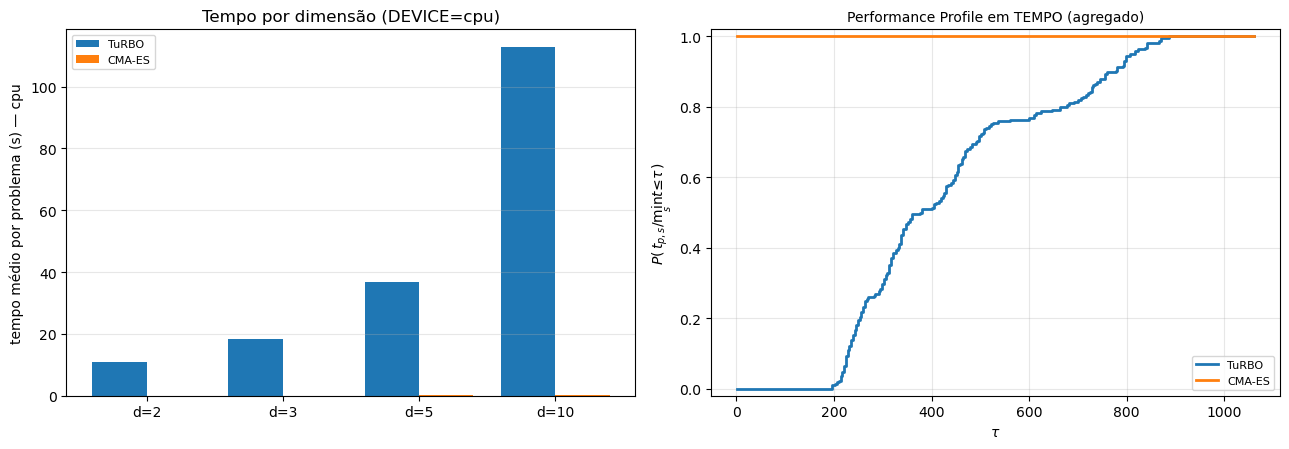

solver               tempo médio (s)   tempo total (s)
TuRBO                         44.727          9661.139
CMA-ES                         0.085            18.383


In [13]:
# (a) barras: tempo médio por solver x dimensão
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
x = np.arange(len(dims)); width = 0.8/len(SOLVERS)
for i, s in enumerate(SOLVERS):
    means = [np.nanmean(time_by_dim[d][s]) for d in dims]
    ax[0].bar(x + i*width, means, width, label=s)
ax[0].set_xticks(x + width*(len(SOLVERS)-1)/2); ax[0].set_xticklabels([f"d={d}" for d in dims])
ax[0].set_ylabel(f"tempo médio por problema (s) — {DEVICE}")
ax[0].set_title(f"Tempo por dimensão (DEVICE={DEVICE})"); ax[0].grid(alpha=0.3, axis="y")
ax[0].legend(fontsize=8)

# (b) perfil de desempenho em TEMPO (agregado)
time_all = {s: np.concatenate([time_by_dim[d][s] for d in dims]) for s in SOLVERS}
draw_profile(ax[1], time_all, logscale=False, title="Performance Profile em TEMPO (agregado)")
ax[1].set_ylabel(r"$P(\,t_{p,s}/\min_s t \leq \tau\,)$")
plt.tight_layout(); plt.show()

print(f"{'solver':<18}{'tempo médio (s)':>18}{'tempo total (s)':>18}")
for s in SOLVERS:
    allt = np.concatenate([time_by_dim[d][s] for d in dims])
    print(f"{s:<18}{np.nanmean(allt):>18.3f}{np.nansum(allt):>18.3f}")

## 10. Como ler e o que ainda dá para endurecer

**Leitura.** Em *avaliações*, $\rho_s(1)$ = fração de vitórias e o platô = robustez. Em *tempo*,
TuRBO tende a pagar caro pelo GP (ainda mais em CPU), enquanto o CMA-ES é barato por avaliação;
o perfil de tempo geralmente favorece o CMA-ES mesmo quando o TuRBO ganha em avaliações — o
*trade-off* clássico de BO: menos avaliações, porém mais caras. Reporte **ambos**.

**Para um trabalho ainda mais sério (sugestões já implementáveis no arcabouço):**
- **Terceiro/quarto solver** (perfis ficam mais informativos com $\ge3$ curvas): COBYLA/COBYQA
  (que você estudou) e/ou *random search* como piso de referência. Basta adicionar a `SOLVERS`.
- **Mais instâncias** (`instance_indices: 1-5`) além de mais seeds: separa dificuldade do
  problema do acaso do solver.
- **Orçamento BBOB cheio** (`budget_per_dim` ~ centenas; total ~$10^3$–$10^4\cdot d$).
- **ECDF de *targets*** no estilo COCO (`cocopp`): em vez de um único alvo, uma malha de alvos
  de precisão — informa muito mais que "atingiu/não atingiu".
- **TuRBO-$m$** (várias regiões de confiança em *batch*) e *batch* Thompson Sampling: é aqui que
  a **GPU** finalmente compensa.
- **Salvar resultados** (`np.savez`/`pickle` de `data`) para reprocessar gráficos sem re-rodar.
- **Múltiplas seeds com IC**: além da mediana, mostrar dispersão (faixas) entre seeds.

> Reprodutibilidade: fixe `seeds`, registre `DEVICE`, e versione `cocoex`, `botorch`,
> `gpytorch`, `torch` e `cma`.